## ------------------------------------------------------------ ###
## Set up environment
## ------------------------------------------------------------ ###

In [113]:
def plot_full_rainfall_event(events_df, event_idx, ens_num, rainfall_cube_dir,
                              ncols=4, cmap="viridis", share_colorbar=True):
    event = events_df.loc[event_idx]

    year = event.hydro_year
    start_idx = event.start_idx
    stop_idx = event.stop_idx
    
    year_cube = get_rainfall_cube_subsection(year, ens_num, rainfall_cube_dir, start_idx, stop_idx)
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(year_cube[0], CATCHMENT_POLY, method='center_point')
    
    year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
    year_cube.data = np.where(year_cube.data == 0, np.nan, year_cube.data)  # NEW: zero rainfall -> NaN
    year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)
    
    cmap_obj = copy.copy(plt.get_cmap(cmap))
    cmap_obj.set_bad(color=(0, 0, 0, 0))  # fully transparent for NaN
    
    n_frames = year_cube.shape[0]  # derive from actual data, not metadata arithmetic
    print(f"Event {event_idx}: year={year}, start_idx={start_idx}, "
          f"stop_idx={stop_idx}, n_frames={n_frames}")

    ncols_ = min(ncols, n_frames)
    nrows = -(-n_frames // ncols_)

    fig, axes = plt.subplots(nrows, ncols_, figsize=(4 * ncols_, 2 * nrows),
                              subplot_kw={"projection": ccrs.PlateCarree()})
    axes = np.atleast_1d(axes).flatten()

    # boundary_plot = boundary_gdf.to_crs(flood_crs)
    
    if share_colorbar:
        vmin = float(np.nanmin(year_cube.data))
        vmax = float(np.nanmax(year_cube.data))
    else:
        vmin = vmax = None

    mesh = None
    for t in range(n_frames):
        ax = axes[t]
        plt.sca(ax)
        # NEW: overlay catchment boundary
        boundary_crs = ccrs.OSGB() 
        ax.add_geometries([CATCHMENT_POLY],crs=boundary_crs,facecolor="none",edgecolor="black",linewidth=1.2,zorder=5,)
        mesh = iplt.pcolormesh(year_cube[t, :, :], axes=ax, cmap=cmap_obj, vmin=vmin, vmax=vmax)
        ax.set_title(f"t={t}")
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[n_frames:]:
        ax.axis("off")

    fig.suptitle(f"Catchment 23 | EM{ens_num} | Event {event_idx+1} "
                 f"(year={year}, {n_frames} steps) | {np.nanmax(year_cube.data):.2f}", fontsize=14)

    if mesh is not None:
        fig.colorbar(mesh, ax=axes[:n_frames], orientation="horizontal",
                     fraction=0.03, pad=0.08, label="Rainfall")

    # plt.tight_layout(rect=[0, 0, 1, 0.96])
    # plt.show()

    # return fig

def plot_multiple_events(events_df, event_indices, ens_num, rainfall_cube_dir, **kwargs):
    """
    Loop plot_full_rainfall_event over a list of event indices.
    """
    figs = []
    for event_idx in event_indices:
        fig = plot_full_rainfall_event(events_df, event_idx, ens_num, rainfall_cube_dir, **kwargs)
        figs.append(fig)
    return figs


def plot_event_with_flood(events_df, event_idx, ens_num, rainfall_cube_dir,
                           flood_5km_path, boundary_gdf,
                           ncols=4, cmap="Blues", flood_cmap="Reds",
                           share_colorbar=True, buffer=5000):
    """
    Plot a full rainfall event (one subplot per timestep) alongside
    the rainfall footprint (any cell that rained at any timestep) and
    the final flood extent for that event.

    Parameters
    ----------
    events_df : DataFrame
        e.g. catchment_23_en1 — MUST be sorted/ordered the same way as
        flood_5km_path's band order (typically sorted by event_num).
    event_idx : label
        .loc-style index into events_df
    ens_num : str
        Ensemble number, e.g. '01'
    rainfall_cube_dir : str
        Path to the ensemble's rainfall cube directory
    flood_5km_path : str
        Path to the multi-band flood extent GeoTIFF/NetCDF for this
        catchment/ensemble/threshold, with one band per event, IN THE
        SAME ORDER as events_df.
    boundary_gdf : GeoDataFrame
        Catchment boundary (any CRS — will be reprojected as needed)
    """
    event = events_df.loc[event_idx-1]
    year = event.hydro_year
    start_idx = event.start_idx
    stop_idx = event.stop_idx

    # -----------------------------
    # RAINFALL DATA
    # -----------------------------
    year_cube = get_rainfall_cube_subsection(year, ens_num, rainfall_cube_dir, start_idx, stop_idx)
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(year_cube[0], CATCHMENT_POLY, method='center_point')
    year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
    year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)

    x_coords = year_cube.coord("projection_x_coordinate").points
    y_coords = year_cube.coord("projection_y_coordinate").points
    rain_extent = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]

    n_frames = year_cube.shape[0]
    print(f"Event {event_idx }: year={year}, start_idx={start_idx}, "
          f"stop_idx={stop_idx}, n_frames={n_frames}")

    footprint = np.any(np.where(np.isnan(year_cube.data), False, year_cube.data > 0), axis=0)
    rainfall_footprint_sum = np.nansum(year_cube.data, axis=0)
    # 
    rainfall_footprint_max = np.full(year_cube.data.shape[1:], np.nan)
    valid = ~np.all(np.isnan(year_cube.data), axis=0)
    rainfall_footprint_max[valid] = np.nanmax(year_cube.data[:, valid], axis=0)
    
    # Location of maximum rainfall intensity
    max_idx = np.nanargmax(rainfall_footprint_max)
    max_row, max_col = np.unravel_index(max_idx, rainfall_footprint_max.shape)
    max_rain = rainfall_footprint_max[max_row, max_col]

    # Coordinates of the maximum-rainfall cell centre
    max_x = x_coords[max_col]
    max_y = y_coords[max_row]

    # Grid-cell dimensions
    dx = np.abs(np.nanmedian(np.diff(x_coords)))
    dy = np.abs(np.nanmedian(np.diff(y_coords)))

    print(f"Maximum rainfall = {max_rain:.2f} mm/hr")
    print(f"Maximum cell = ({max_x:.0f}, {max_y:.0f})")    
    
    
    cmap_obj = copy.copy(plt.get_cmap(cmap))
    cmap_obj.set_bad(color=(0, 0, 0, 0))  # transparent NaN (outside catchment mask)

    if share_colorbar:
        vmin = float(np.nanmin(year_cube.data))
        vmax = float(np.nanmax(year_cube.data))
    else:
        vmin = vmax = None

    # -----------------------------
    # FLOOD DATA (band = position of event in events_df)
    # -----------------------------
    event_position = events_df.index.get_loc(event_idx)  # rasterio bands are 1-indexed

    with rasterio.open(flood_5km_path) as src:
        crs = src.crs
        nodata = src.nodata
        if event_position > src.count:
            raise ValueError(
                f"Event position {event_position} exceeds number of bands in flood file "
                f"({src.count}). Check events_df ordering matches the flood file.")
        flood_data = src.read(event_position).astype(float)
        transform = src.transform
        flood_extent = plotting_extent(flood_data, transform)

    if nodata is not None:
        flood_data[flood_data == nodata] = np.nan
    flood_data[flood_data == 0] = np.nan

    boundary_plot = boundary_gdf.to_crs(crs)
    xmin, ymin, xmax, ymax = boundary_plot.total_bounds
    xmin, xmax = xmin - buffer, xmax + buffer
    ymin, ymax = ymin - buffer, ymax + buffer

    # -----------------------------
    # LAYOUT
    # -----------------------------
    ncols_ts = min(ncols, n_frames)
    nrows_ts = -(-n_frames // ncols_ts)  # ceil division

    fig = plt.figure(figsize=(4 * ncols_ts, 4 * nrows_ts + 4))
    gs = gridspec.GridSpec(nrows_ts + 1, ncols_ts, figure=fig,
                            height_ratios=[1] * nrows_ts + [1.3])

    # --- Top: per-timestep rainfall ---
    mesh = None
    for t in range(n_frames):
        row, col = divmod(t, ncols_ts)
        ax = fig.add_subplot(gs[row, col])
        mesh = ax.imshow(year_cube[t, :, :].data, extent=rain_extent, origin="lower",
                          cmap=cmap_obj, vmin=vmin, vmax=vmax)
        boundary_plot.boundary.plot(ax=ax, edgecolor="black", linewidth=1)
        ax.set_title(f"t={t}")
        ax.axis("off")

    # Hide unused slots in the timeseries grid
    for t in range(n_frames, nrows_ts * ncols_ts):
        row, col = divmod(t, ncols_ts)
        fig.add_subplot(gs[row, col]).axis("off")

    # --- Bottom left: maximum rainfall intensity ---
    ax_fp = fig.add_subplot(gs[nrows_ts, 0:ncols_ts // 3])
    plot = ax_fp.imshow(rainfall_footprint_max, extent=rain_extent, origin="lower", cmap="Blues")
    boundary_plot.boundary.plot(ax=ax_fp, edgecolor="black", linewidth=1.2)
    ax_fp.set_xlim(xmin, xmax)
    ax_fp.set_ylim(ymin, ymax)
    ax_fp.set_title("Maximum rainfall intensity")
    ax_fp.axis("off")


    # --- Bottom middle: total rainfall ---
    ax_fp1 = fig.add_subplot(gs[nrows_ts, ncols_ts // 3:2 * ncols_ts // 3])
    plot = ax_fp1.imshow(rainfall_footprint_sum, extent=rain_extent, origin="lower", cmap="Blues")
    boundary_plot.boundary.plot(ax=ax_fp1, edgecolor="black", linewidth=1.2)
    ax_fp1.set_xlim(xmin, xmax)
    ax_fp1.set_ylim(ymin, ymax)
    ax_fp1.set_title("Total rainfall")
    ax_fp1.axis("off")


    # --- Bottom right: flood extent ---
#     ax_fl = fig.add_subplot(gs[nrows_ts, 2 * ncols_ts // 3:])
#     plot = ax_fl.imshow(flood_data, extent=flood_extent, origin="upper", cmap=flood_cmap)
#     # fig.colorbar(plot, ax=ax_fl, shrink=0.8, label="Flooded area (km²)")
#     boundary_plot.boundary.plot(ax=ax_fl, edgecolor="red", linewidth=2)
#     ax_fl.set_xlim(xmin, xmax)
#     ax_fl.set_ylim(ymin, ymax)
#     ax_fl.set_title(f"Flood extent (band {event_position})")
#     ax_fl.axis("off")
    
    # --- Bottom right: flood extent ---
    ax_fl = fig.add_subplot(gs[nrows_ts, 2 * ncols_ts // 3:])
    plot = ax_fl.imshow(flood_data, extent=flood_extent, origin="upper", cmap=flood_cmap)

    boundary_plot.boundary.plot(ax=ax_fl, edgecolor="red", linewidth=2)

    # Highlight maximum-rainfall cell
    max_cell = Rectangle((max_x - dx / 2, max_y - dy / 2),dx,dy,fill=False,edgecolor="black",linewidth=2.5)
    ax_fl.add_patch(max_cell)

    ax_fl.set_xlim(xmin, xmax)
    ax_fl.set_ylim(ymin, ymax)
    ax_fl.set_title(f"Flood extent")
    ax_fl.axis("off")    
    
    
    fig.suptitle(f"Catchment {TARGET_HA} | EM{ens_num} | Event {event_idx} (year={year}) | max precip is {np.nanmax(year_cube.data):.2f}",
                 fontsize=14)

    if mesh is not None:
        fig.colorbar(mesh, ax=fig.axes[:n_frames], orientation="horizontal",
                     fraction=0.02, pad=0.05, label="Rainfall")

    #plt.tight_layout(rect=[0, 0, 1, 0.96])
    # return fig


def plot_multiple_events_with_flood(events_df, event_indices, ens_num, rainfall_cube_dir,
                                     flood_5km_path, boundary_gdf, **kwargs):
    """Loop plot_event_with_flood over a list of event indices."""
    figs = []
    for event_idx in event_indices:
        fig = plot_event_with_flood(events_df, event_idx, ens_num, rainfall_cube_dir,
                                     flood_5km_path, boundary_gdf, **kwargs)
        figs.append(fig)
    return figs

In [100]:
import glob
import os
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import sys
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from rasterio.warp import Resampling, reproject
from rasterio.features import geometry_mask
from rasterio.enums import Resampling
from rasterio.mask import mask
from rasterio.plot import plotting_extent
from shapely import box
import cartopy.crs as ccrs
import iris.plot as iplt
import iris
from iris.analysis.cartography import unrotate_pole
import rioxarray
import copy
from matplotlib.patches import Rectangle

# --------------------------
# Configuration — edit these
# --------------------------
DEM_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/dem/"
NETCDF_DIR = "/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/"
event_details_fp = 'EventDetails'

sys.path.insert(1, '../ProcessEvents')
from functions import filter_closer_to_catchment_xr_bounds
from functions_stage2 import get_rainfall_cube_subsection,mask_cube_with_catchment_full_grid, subset_cube_to_bbox
from helper_functions import extract_ha_num, find_matching_netcdf

from config import  CATCHMENTS

## ------------------------------------------------------------ ###
## Get dataset containing events from across all catchments
## ------------------------------------------------------------ ###

In [120]:
TARGET_HA = '6'
ens_num = '01'

boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(TARGET_HA)]
CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

In [121]:
# Get rainfall event details
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_added_soilvars.pkl"
rainfall_events_all_df = pd.read_pickle(fp)

# Filter to just the catchmand ensemble member of interest
this_catchment = rainfall_events_all_df[rainfall_events_all_df['catchment_num']==TARGET_HA].copy()
this_catchment_this_ens = this_catchment[this_catchment['ens'] ==int(ens_num)].copy()
this_catchment_this_ens['hydro_year'] = this_catchment_this_ens['start_year'].where(this_catchment_this_ens['month'] != 12,
        this_catchment_this_ens['start_year'] + 1)
this_catchment_this_ens.reset_index(inplace=True, drop=True)

In [122]:
rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"

# Plot a single event by its index label
# plot_full_rainfall_event(catchment_23_en1, event_idx=catchment_23_en1.index[4],
#                           ens_num=ens_num, rainfall_cube_dir=rainfall_cube_dir)

# Plot the first 5 events by position
# event_indices = this_catchment_this_ens.index[:5]
# plot_multiple_events(this_catchment_this_ens, event_indices, ens_num, rainfall_cube_dir)

# Or plot specific ones you've picked out, e.g. the 3rd and 7th rows
# event_indices = catchment_23_en1.index[[1]]
# event_indices
# plot_multiple_events(catchment_23_en1, event_indices, ens_num, rainfall_cube_dir)

## ------------------------------------------------------------ ###
## Plot figure showing cells most hit by floods
## ------------------------------------------------------------ ###

In [123]:
flood_5km_path = (f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/"
    f"Catchment_{TARGET_HA}/Ens{ens_num}_{TARGET_HA}/10cm/"
    f"flooded_area_5km_total_Ens{ens_num}_{TARGET_HA}_10cm.nc")

with rasterio.open(flood_5km_path) as src:
    flood_frequency = np.zeros((src.height, src.width), dtype=float)
    flood_transform = src.transform
    flood_crs = src.crs

    for event in range(1, src.count + 1):
        flood_data = src.read(event)
        flood_frequency += flood_data > 0
        print(np.nanmax(flood_data))

flood_frequency[flood_frequency == 0] = np.nan

0.0
0.42479998
0.053099997
0.34739998
0.0018
0.0
0.0045
0.0819
0.3744
0.1647
0.0
0.0027
0.17819999
0.0081
0.0063
0.0027
0.0099
0.1584
0.081
0.035099998
0.0
0.0216
0.2556
0.0
0.0063
0.0297
0.7641
0.0
1.1511


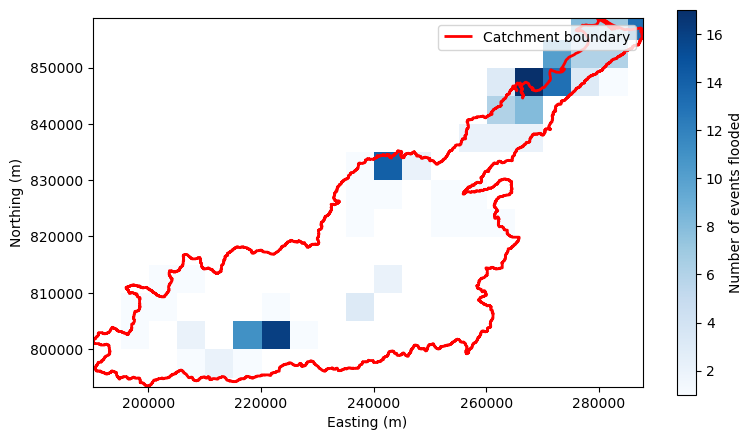

In [124]:
extent = plotting_extent(flood_frequency, flood_transform)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(flood_frequency,extent=extent,origin="upper",cmap="Blues")

boundary_plot = boundary_gdf.to_crs(flood_crs)

boundary_plot.boundary.plot(ax=ax,edgecolor="red",linewidth=2,label="Catchment boundary")

# Zoom to catchment
xmin, ymin, xmax, ymax = boundary_plot.total_bounds

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

cbar = fig.colorbar(im, ax=ax, shrink=0.5)
cbar.set_label("Number of events flooded")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend()

plt.tight_layout()
plt.show()

## Plot flooded area for each event

Number of events: 29


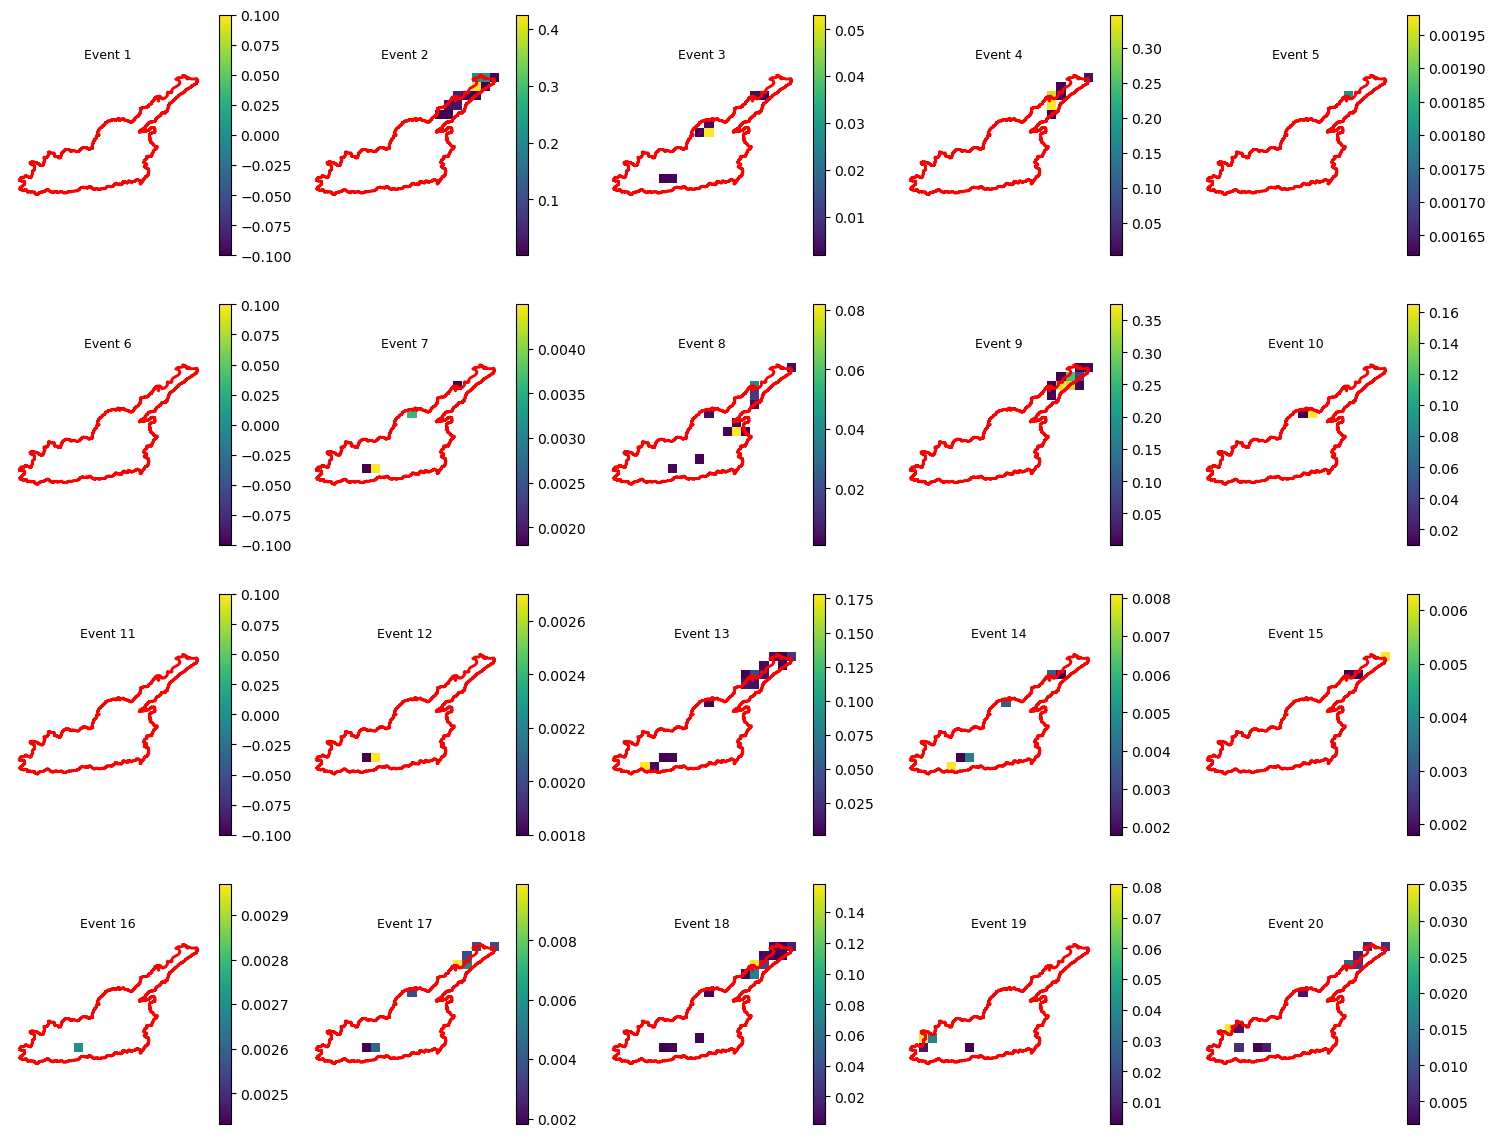

In [125]:
# Read raster information once
with rasterio.open(flood_5km_path) as src:
    n_events = src.count
    transform = src.transform
    crs = src.crs
    nodata = src.nodata

print(f"Number of events: {n_events}")

# Catchment in the same CRS as the flood raster
boundary_plot = boundary_gdf.to_crs(crs)

# Catchment extent
xmin, ymin, xmax, ymax = boundary_plot.total_bounds

# Add a small buffer around catchment
buffer = 5000

xmin -= buffer
xmax += buffer
ymin -= buffer
ymax += buffer

# Create figure
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

with rasterio.open(flood_5km_path) as src:

    for event in range(1, 20 + 1):
    # for event in range(1, 2):    
        flood_data = src.read(event).astype(float)
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

        # Set nodata and non-flooded pixels to NaN
        if nodata is not None:
            flood_data[flood_data == nodata] = np.nan
        flood_data[flood_data == 0] = np.nan
        
        # Flooded footprint
        # footprint = flood_data > 0

        ax = axes[event - 1]

        # Plot using the actual raster coordinates
        #extent = plotting_extent(flood_data, transform)

        plot = ax.imshow(flood_data,extent=extent,origin="upper")
        fig.colorbar(plot, ax=ax, shrink = 0.8)
        boundary_plot.boundary.plot(ax=ax,edgecolor="red",linewidth=2,label="Catchment boundary")
        # Same plotting extent for every subplot
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        ax.set_title(f"Event {event}", fontsize=9)
        ax.axis("off")

# Hide any unused axes
for ax in axes[n_events:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Event 1: year=1994, start_idx=4737, stop_idx=4754, n_frames=17
Maximum rainfall = 44.73 mm/hr
Maximum cell = (192500, 797500)
Event 5: year=2007, start_idx=6583, stop_idx=6604, n_frames=21
Maximum rainfall = 42.24 mm/hr
Maximum cell = (207500, 812500)
Event 6: year=2027, start_idx=4714, stop_idx=4728, n_frames=14
Maximum rainfall = 31.23 mm/hr
Maximum cell = (212500, 802500)
Event 7: year=2030, start_idx=8499, stop_idx=8519, n_frames=20
Maximum rainfall = 30.88 mm/hr
Maximum cell = (192500, 797500)
Event 11: year=2048, start_idx=4523, stop_idx=4539, n_frames=16
Maximum rainfall = 30.32 mm/hr
Maximum cell = (197500, 797500)
Event 12: year=2048, start_idx=4881, stop_idx=4899, n_frames=18
Maximum rainfall = 34.64 mm/hr
Maximum cell = (192500, 802500)
Event 15: year=2051, start_idx=6929, stop_idx=6954, n_frames=25
Maximum rainfall = 36.74 mm/hr
Maximum cell = (192500, 797500)


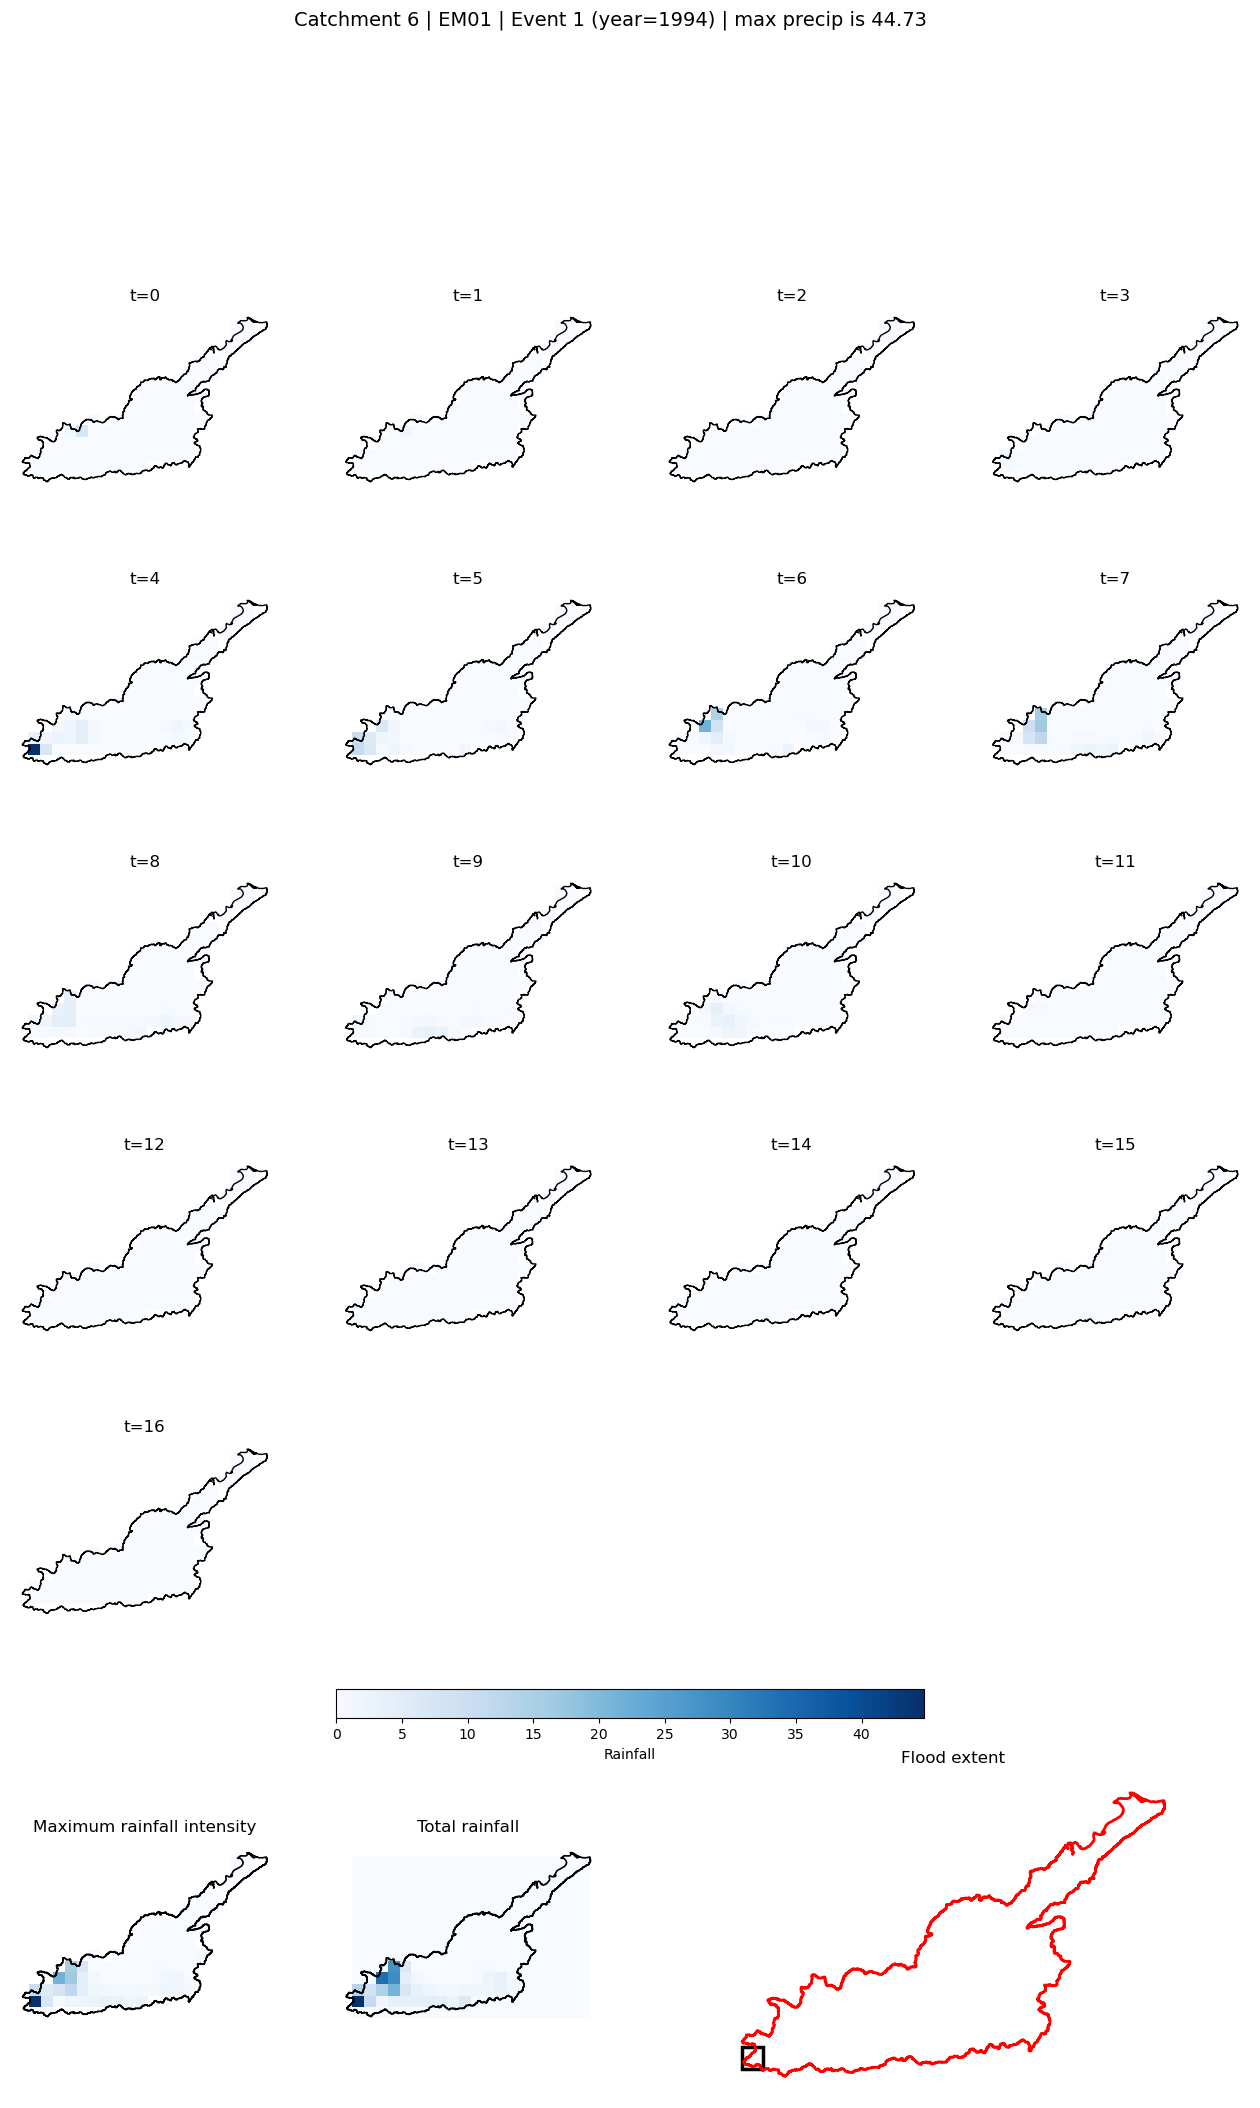

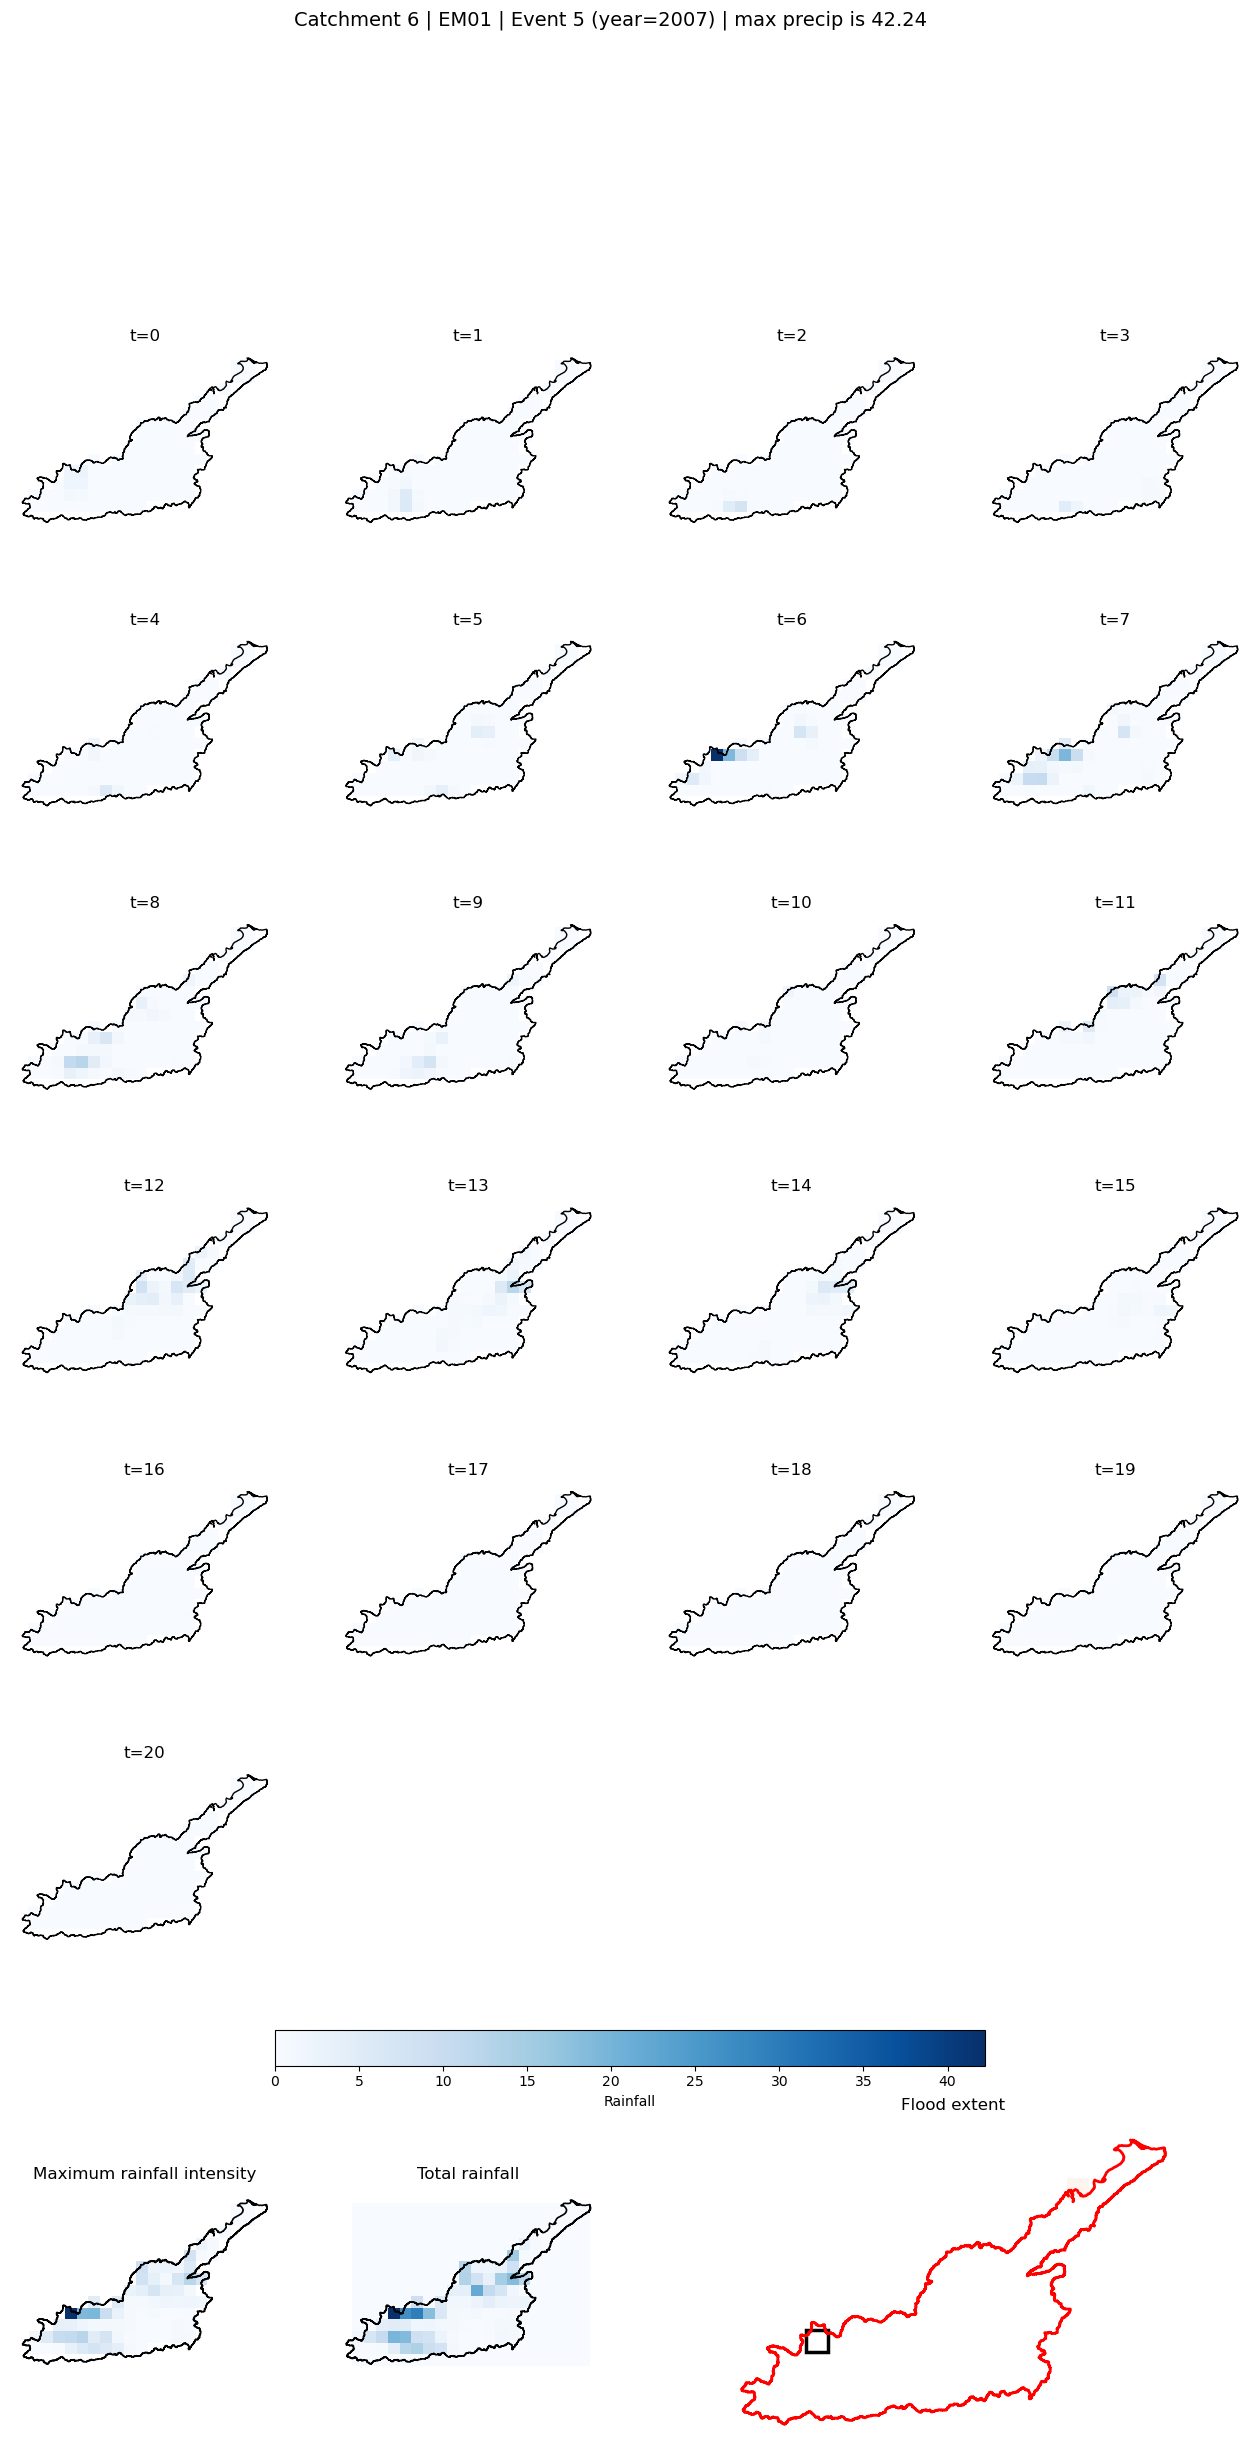

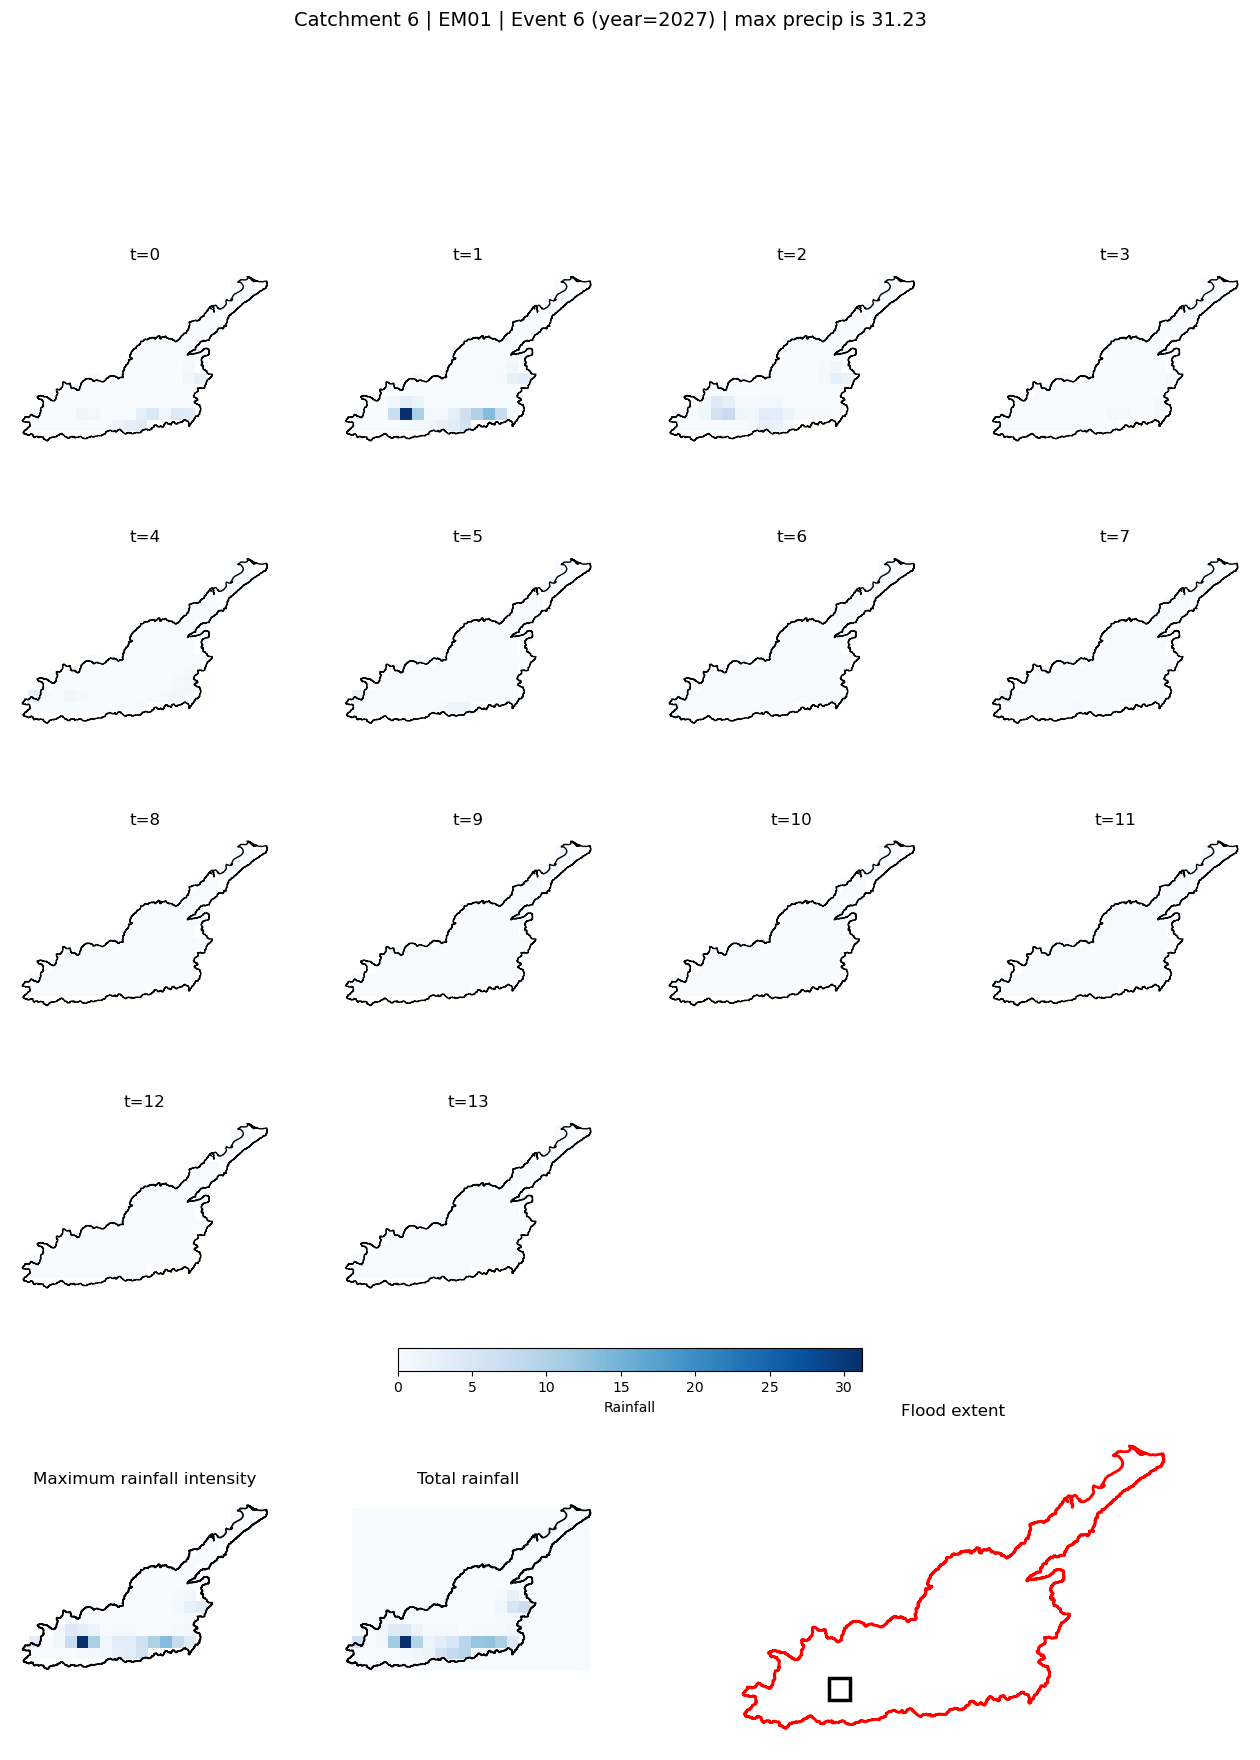

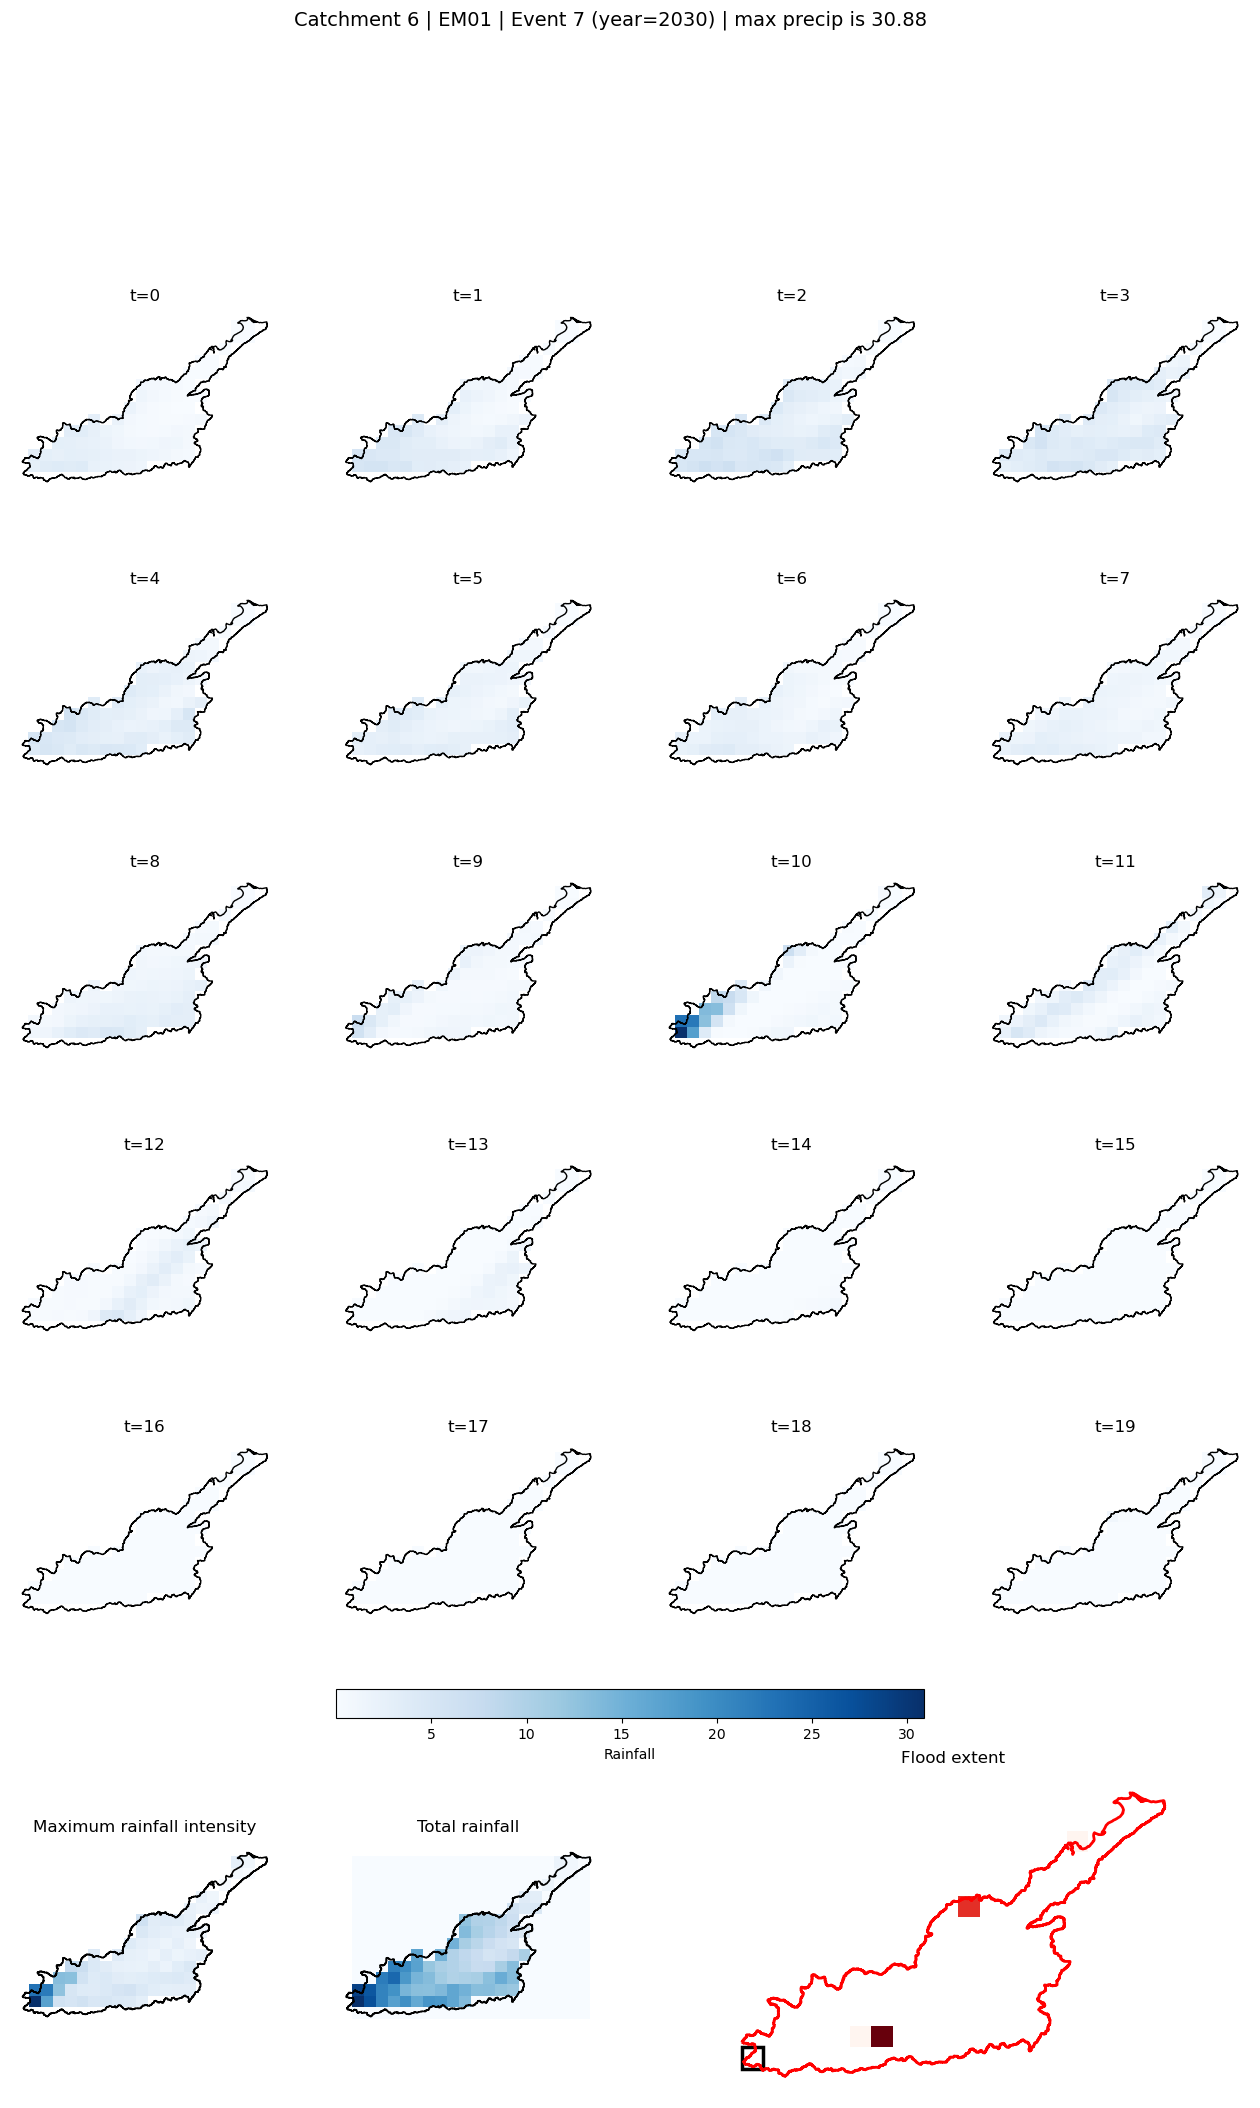

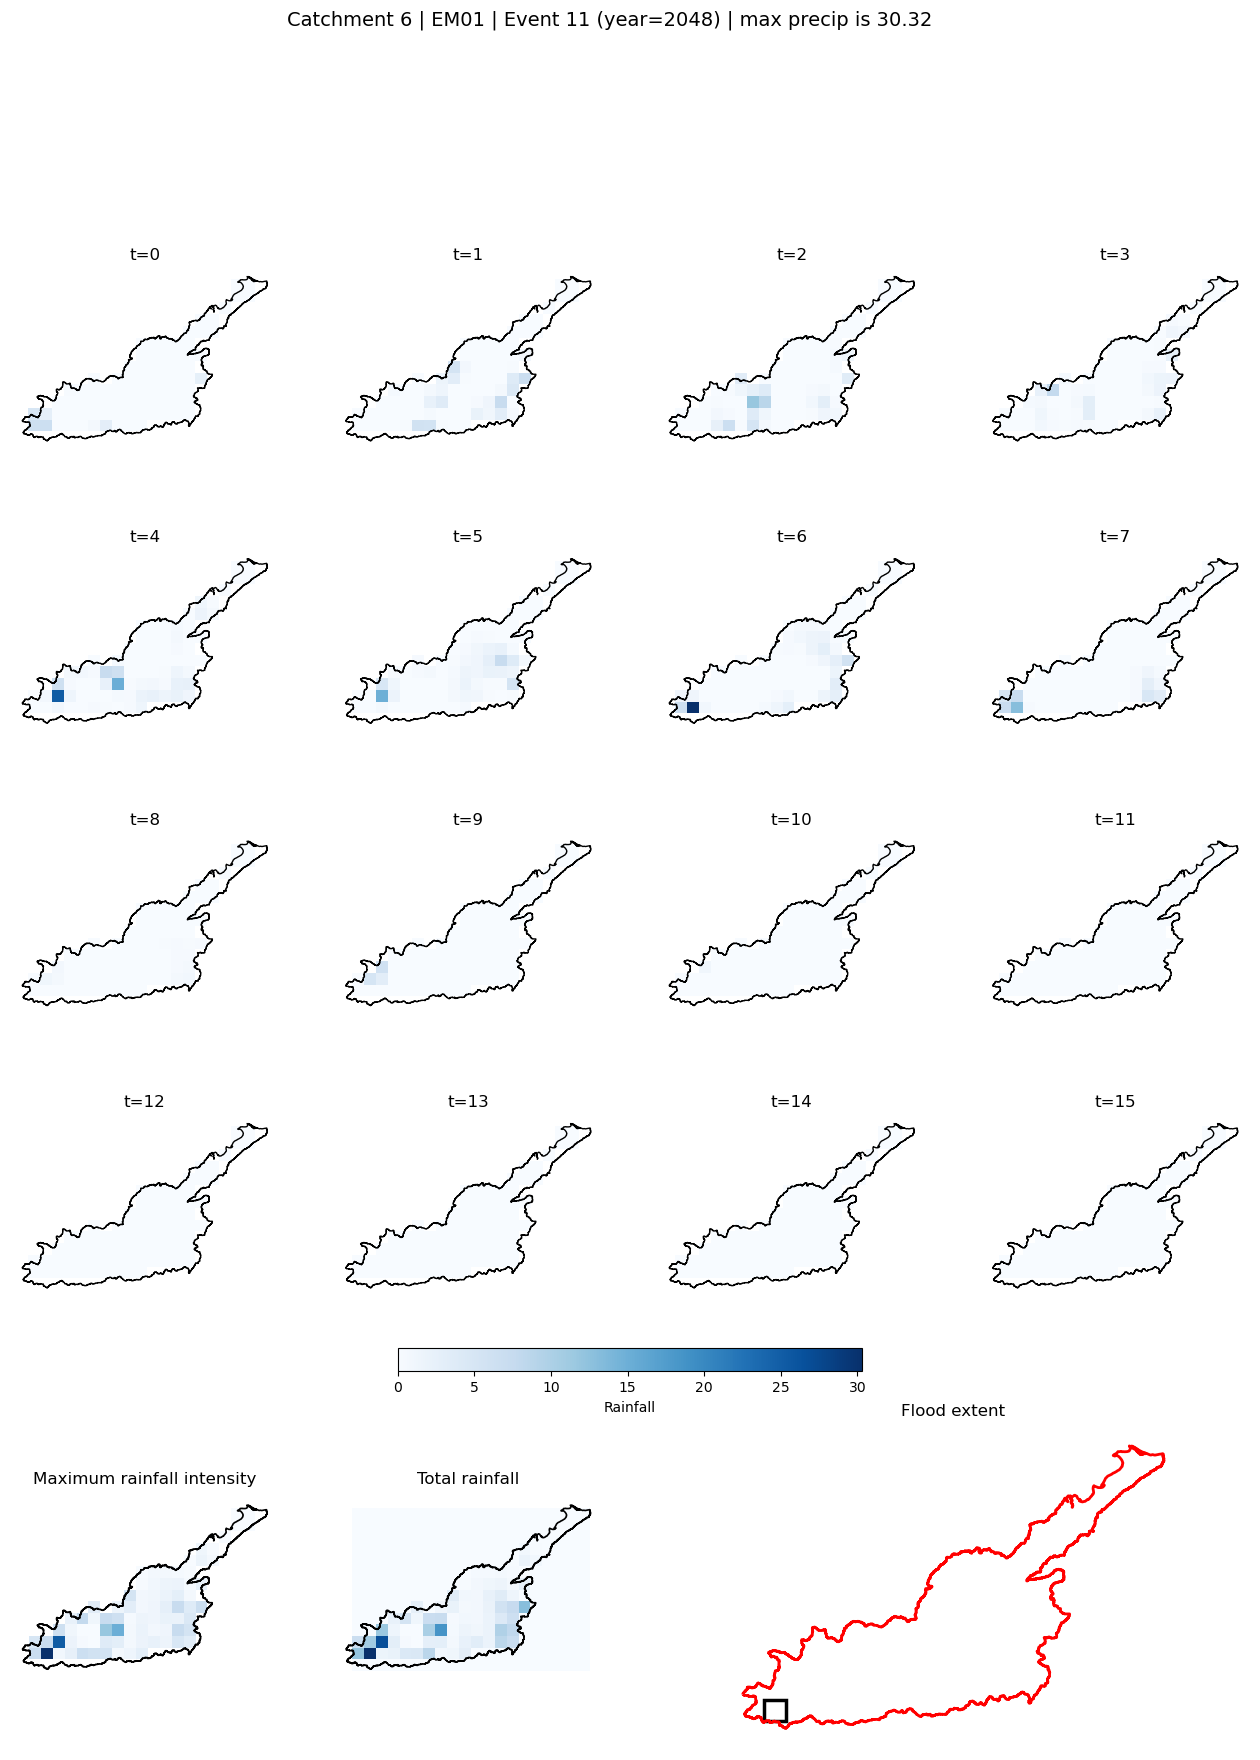

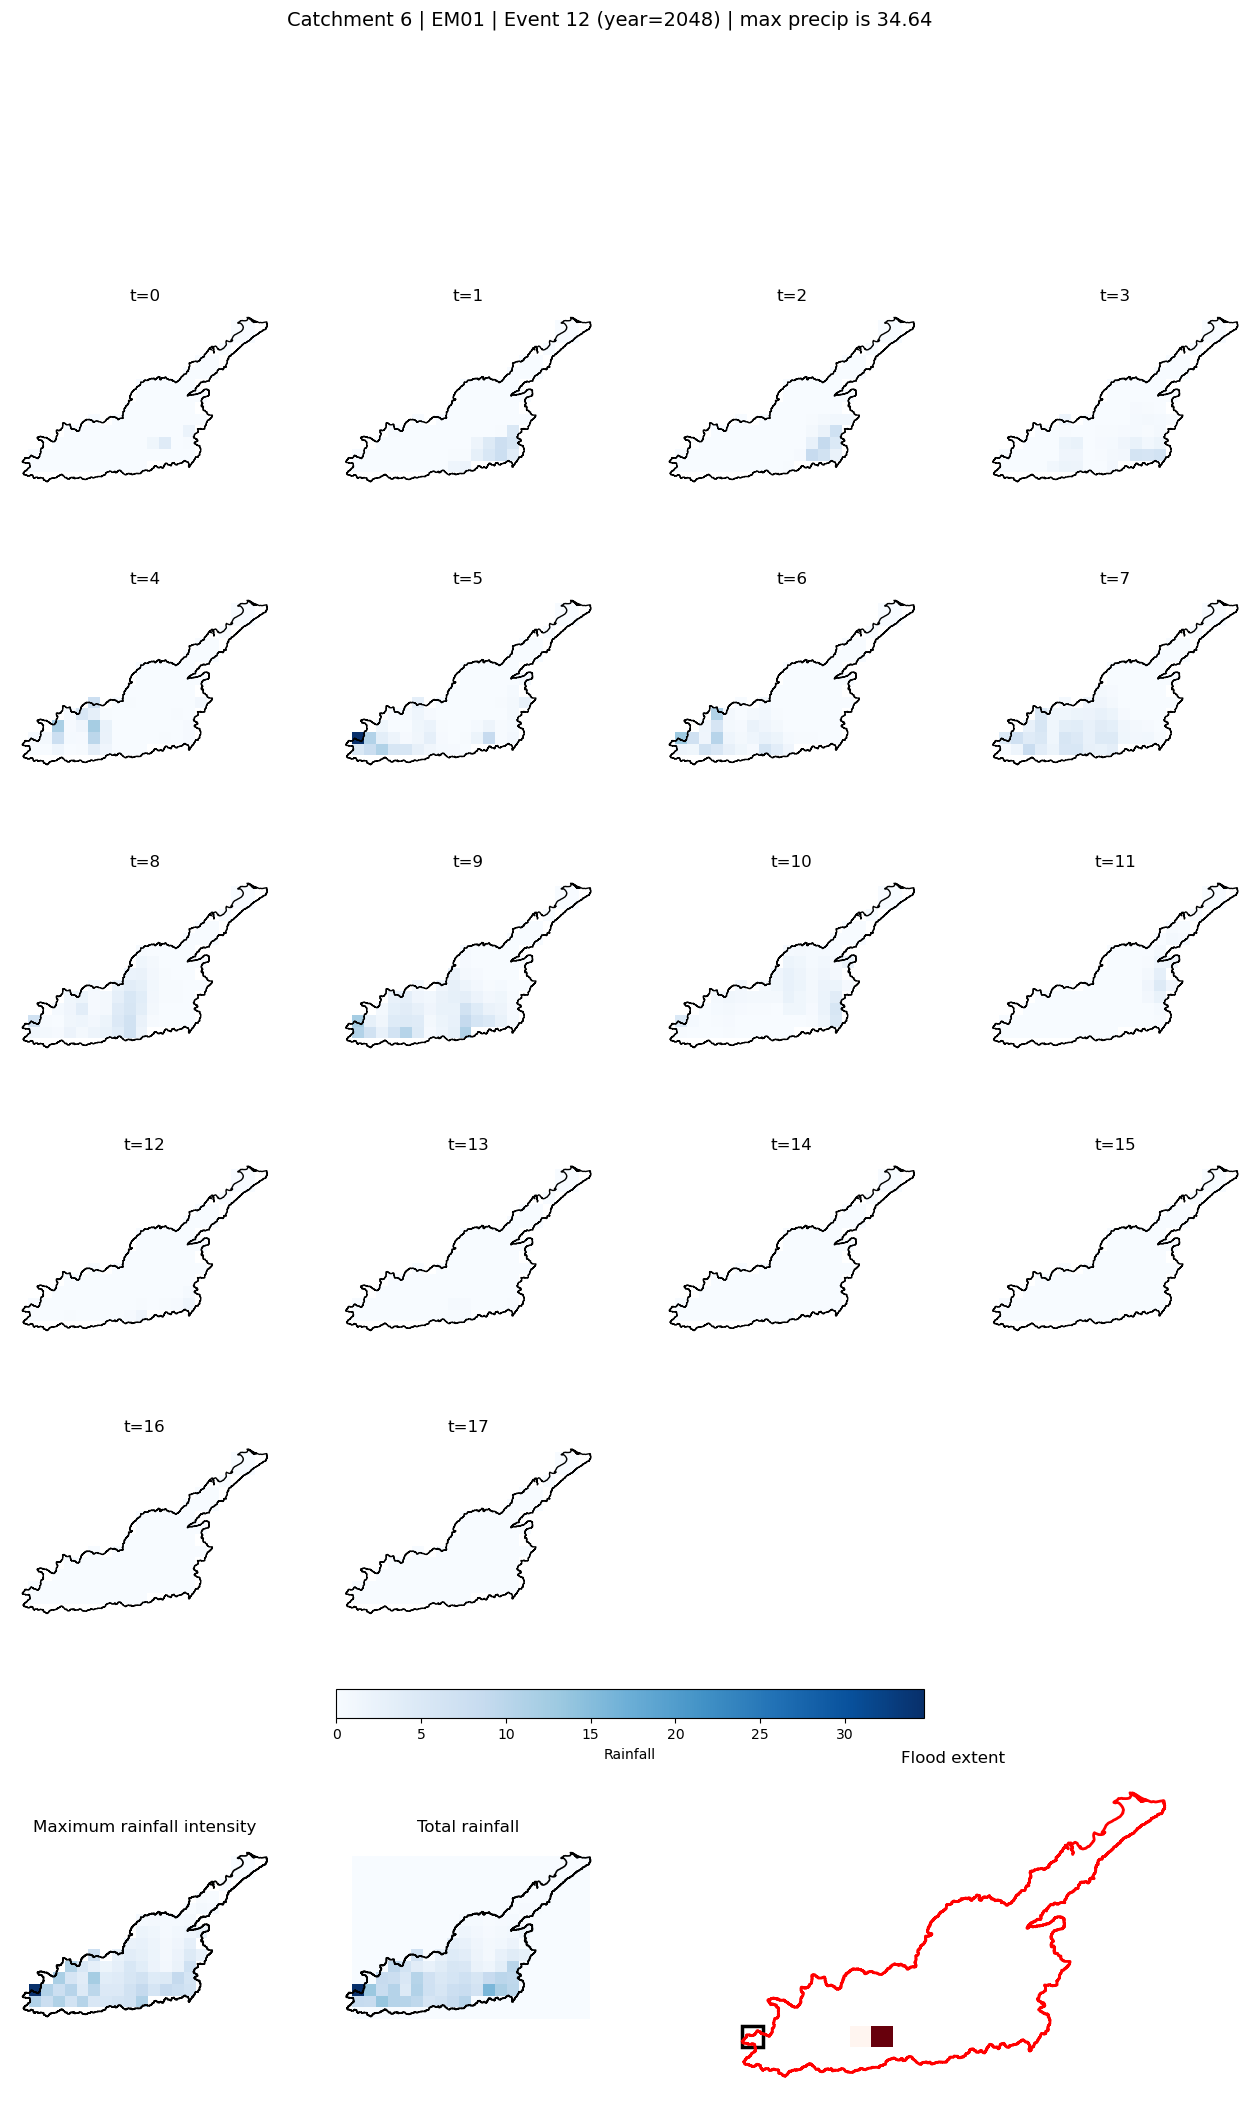

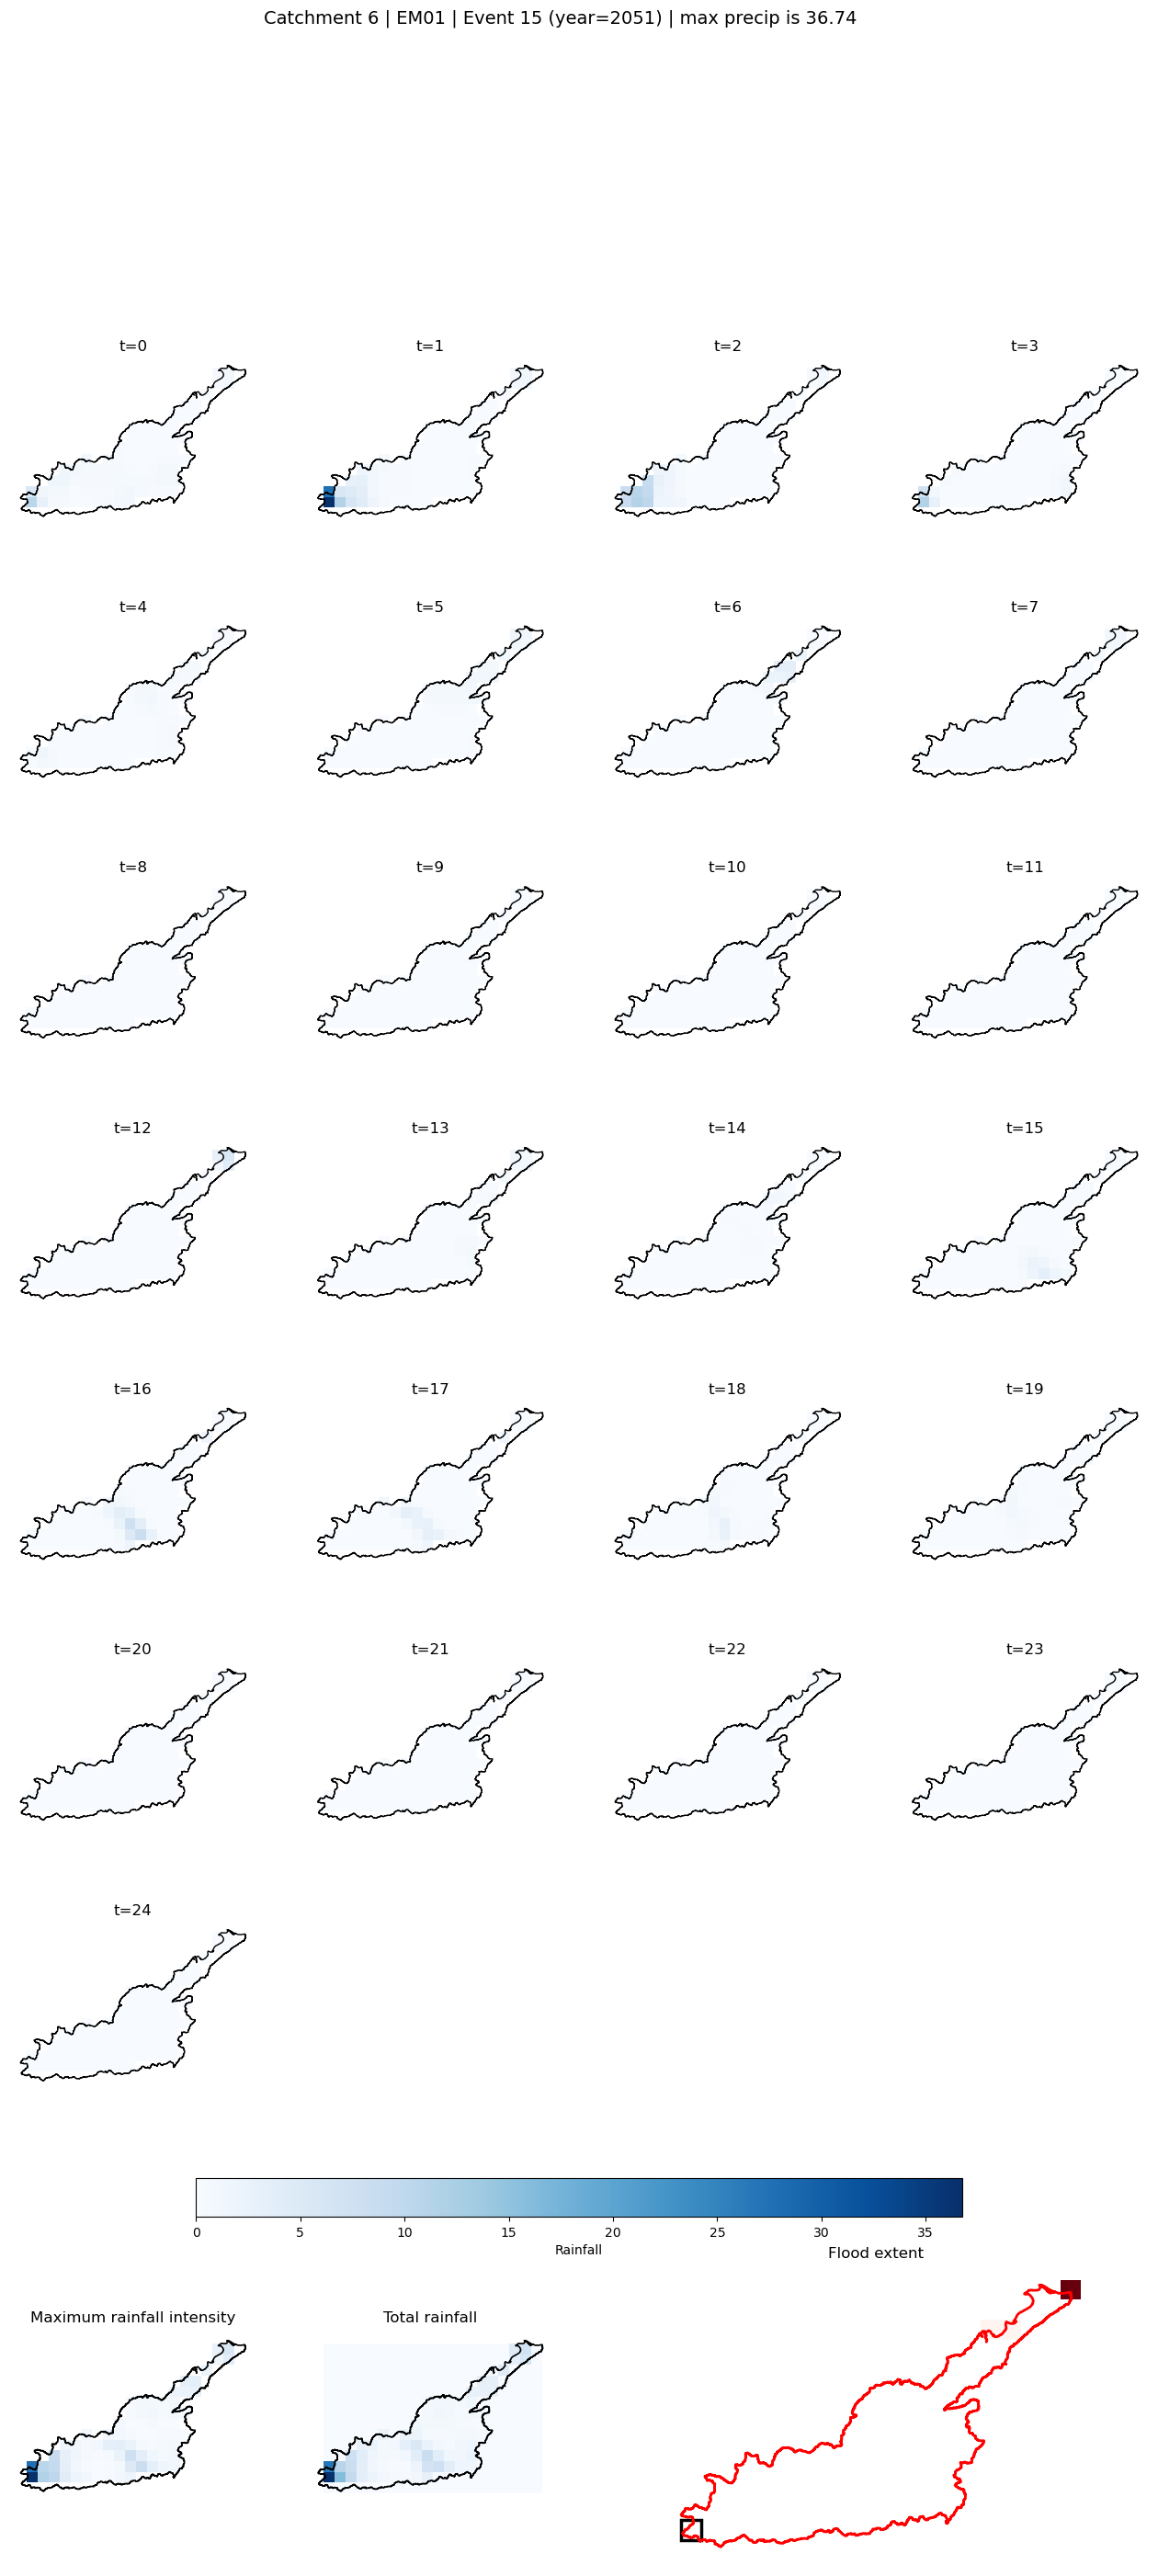

In [127]:
# IMPORTANT: sort to match flood file's band order before resetting index
this_catchment_this_ens = this_catchment_this_ens.sort_values('event_num').reset_index(drop=True)

# # --- Plot a single event ---
# fig = plot_event_with_flood(this_catchment_this_ens, event_idx=8,
#     ens_num=ens_num, rainfall_cube_dir=rainfall_cube_dir,
#     flood_5km_path=flood_5km_path, boundary_gdf=boundary_gdf)
# plt.show()

# --- Plot the first 5 events ---
figs = plot_multiple_events_with_flood(this_catchment_this_ens, event_indices=[1,5,6,7,11,12,15],
    ens_num=ens_num, rainfall_cube_dir=rainfall_cube_dir,
    flood_5km_path=flood_5km_path, boundary_gdf=boundary_gdf)
for f in figs:
    plt.show()

### Saving events to file for checking?

In [11]:
# OUT_DIR = "/scratch/hydro4/users/kv25483/FutureFlood/Data/QA_tif/catchment_23_en1_peak_slices"
# os.makedirs(OUT_DIR, exist_ok=True)

# first_10_events = catchment_23_en1.iloc[:10]
# first_10_events.reset_index(inplace=True, drop=True)

# for i, event in first_10_events.iterrows():
#     year = event.hydro_year
#     start_idx = event.start_idx
#     stop_idx = event.stop_idx
#     t_local = event.t_local

#     print(f"[{i}] Processing event: year={year}, start_idx={start_idx}, stop_idx={stop_idx}, t_local={t_local}")

#     year_cube = get_rainfall_cube_subsection(year, ens_num, rainfall_cube_dir, start_idx, stop_idx)
#     year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
#     year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)
    
#     peak_slice = year_cube[t_local, :, :]

#     # --- Convert Iris cube slice -> xarray DataArray ---
#     da = xr.DataArray.from_iris(peak_slice)

#     # --- Write CRS ---
#     # Adjust this depending on what grid your rainfall data is actually on.
#     # If it's already British National Grid (has projection_x/y_coordinate):
#     if "projection_x_coordinate" in da.coords:
#         da = da.rename({"projection_x_coordinate": "x", "projection_y_coordinate": "y"})
#         da = da.rio.write_crs("EPSG:27700")
#     # If it's rotated pole (common for raw UKCP18/CPM), you'll need to
#     # unrotate first, or write the rotated-pole CRS proj string instead.
#     else:
#         raise ValueError("Unexpected coordinate system — check da.coords before writing CRS")

#     out_path = os.path.join(OUT_DIR,f"catchment23_en{ens_num}_event{i+1}_peak_t{t_local}.tif")
#     da.astype("float32").rio.write_nodata(np.nan, inplace=True)
#     da.rio.to_raster(out_path)
#     print(f"    Saved {out_path}")